In [1]:
import os
import shutil
import numpy as np

# --- Paths and Ratios ---
extracted_path = "/content/drive/MyDrive/Colab Notebooks/covid19normalpneumonia-ct-images"
classesPath = ['Normal_CT', 'pneumonia_CT']
train_ratio, val_ratio, test_ratio = 0.6, 0.2, 0.2

# --- Prepare Balanced Dataset ---
class_file_counts = {}
for cls in classesPath:
    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    class_file_counts[cls] = len(allFileNames)

min_files = min(class_file_counts.values())

for cls in classesPath:
    os.makedirs(os.path.join('./train/', cls), exist_ok=True)
    os.makedirs(os.path.join('./val/', cls), exist_ok=True)
    os.makedirs(os.path.join('./test/', cls), exist_ok=True)

    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    np.random.shuffle(allFileNames)
    balanced_FileNames = allFileNames[:min_files]

    train_count = int(train_ratio * min_files)
    val_count = int(val_ratio * min_files)
    test_count = min_files - train_count - val_count

    # Calculate the split sizes
    total_files = len(balanced_FileNames)
    train_FileNames = balanced_FileNames[:train_count]
    val_FileNames = balanced_FileNames[train_count:train_count + val_count]
    test_FileNames = balanced_FileNames[train_count + val_count:]

    # Print statistics for each class
    print(f'Total {cls} after balancing: {total_files}')
    print(f'Training: {len(train_FileNames)}')
    print(f'Validation: {len(val_FileNames)}')
    print(f'Testing: {len(test_FileNames)}\n')

    for name in train_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./train/', cls))
    for name in val_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./val/', cls))
    for name in test_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./test/', cls))

Total Normal_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425

Total pneumonia_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425



In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=True)
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)

Found 2542 images belonging to 2 classes.
Found 846 images belonging to 2 classes.
Found 850 images belonging to 2 classes.


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, Conv2D,
    BatchNormalization, Multiply, Reshape, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow.keras.backend as K

# -------------------------------
# Hybrid BCE + Focal loss
def hybrid_bce_focal(gamma=2.0, alpha=0.25, focal_weight=0.6):
    bce = tf.keras.losses.BinaryCrossentropy()

    def focal_loss(y_true, y_pred):
        y_true_f = K.cast(y_true, dtype='float32')
        y_pred_f = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        pt = tf.where(K.equal(y_true_f, 1), y_pred_f, 1 - y_pred_f)
        loss = -alpha * K.pow(1. - pt, gamma) * K.log(pt)
        return K.mean(loss)

    def loss(y_true, y_pred):
        bce_loss = bce(y_true, y_pred)
        focal = focal_loss(y_true, y_pred)
        return focal_weight * focal + (1 - focal_weight) * bce_loss

    return loss

# -------------------------------
# Squeeze-and-Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

# -------------------------------
# Data - Compute class weights
X_train_full, y_train_full = [], []
for i in range(len(train_generator)):
    X_batch, y_batch = train_generator[i]
    X_train_full.append(X_batch)
    y_train_full.append(y_batch)
    if len(X_train_full) * 16 >= train_generator.n:
        break
X_train_full = np.concatenate(X_train_full)
y_train_full = np.concatenate(y_train_full)

X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
class_weights_dict = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)))

from tensorflow.keras.applications import DenseNet121

# -------------------------------
# DenseNet121 Model (Replaces ResNet50)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
for layer in base_model.layers[-100:]:  # Optionally fine-tune last 100 layers
    layer.trainable = True

x = base_model.output
x = squeeze_excite_block(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=output)


# -------------------------------
# Compile model with only Tversky loss
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=hybrid_bce_focal(alpha=0.25, gamma=2.0, focal_weight=0.6),
              metrics=['accuracy'])

# -------------------------------
# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=5, min_lr=1e-7)

# -------------------------------
# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# -------------------------------
# Validation evaluation
val_preds = (model.predict(val_generator) > 0.5).astype(int)
val_labels = val_generator.classes
print("Validation:",
      f"Accuracy: {accuracy_score(val_labels, val_preds)}",
      f"Precision: {precision_score(val_labels, val_preds)}",
      f"Recall: {recall_score(val_labels, val_preds)}",
      f"F1: {f1_score(val_labels, val_preds)}")

# -------------------------------
# Test evaluation
X_test_full, y_test_full = [], []
for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    X_test_full.append(X_batch)
    y_test_full.append(y_batch)
    if len(X_test_full) * 16 >= test_generator.n:
        break
X_test_full = np.concatenate(X_test_full)
y_test_full = np.concatenate(y_test_full)

test_preds = (model.predict(X_test_full) > 0.5).astype(int)
print("Test:",
      f"Accuracy: {accuracy_score(y_test_full, test_preds)}",
      f"Precision: {precision_score(y_test_full, test_preds)}",
      f"Recall: {recall_score(y_test_full, test_preds)}",
      f"F1: {f1_score(y_test_full, test_preds)}")


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7173 - loss: 0.2612

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.7179 - loss: 0.2608 - val_accuracy: 0.6170 - val_loss: 0.4788 - learning_rate: 1.0000e-04
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 558s 4s/step - accuracy: 0.9173 - loss: 0.0981 - val_accuracy: 0.8818 - val_loss: 0.1144 - learning_rate: 1.0000e-04
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 559s 4s/step - accuracy: 0.9476 - loss: 0.0700 - val_accuracy: 0.9019 - val_loss: 0.1308 - learning_rate: 1.0000e-04
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 564s 4s/step - accuracy: 0.9680 - loss: 0.0440 - val_accuracy: 0.9303 - val_loss: 0.0874 - learning_rate: 1.0000e-04
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.9816 - loss: 0.0305 - val_accuracy: 0.9113 - val_loss: 0.1070 - learning_rate: 1.0000e-04
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 549s 4s/step - accuracy: 0.9801 - loss: 0.0286 - val_accuracy: 0.9137 - val_loss: 0.1220 - learning_rate: 1.0000e-04
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.97

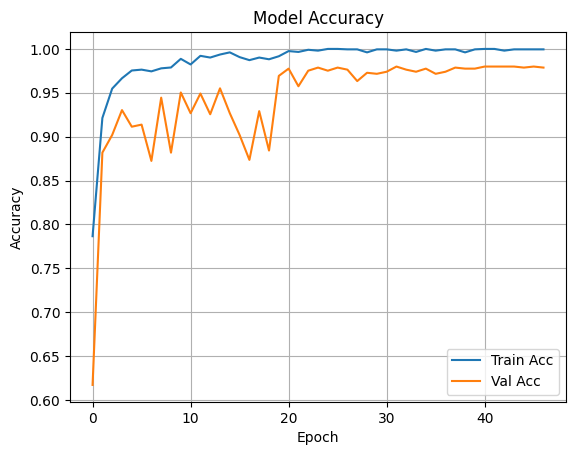

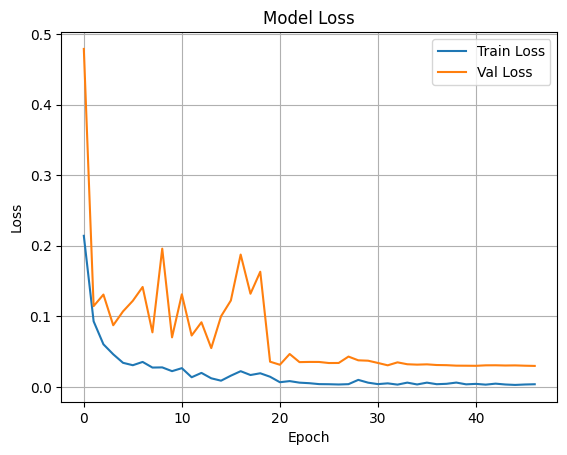

In [4]:
import matplotlib.pyplot as plt
# --- Plots ---
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 914ms/step


<Figure size 800x600 with 0 Axes>

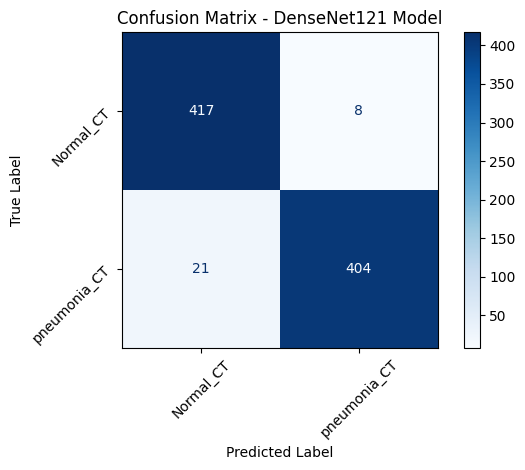

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate model on test data
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()  # Convert probabilities to class labels (0 or 1)

# True labels
y_true = test_generator.classes  # Assuming test_generator has the true labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - DenseNet121 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
model.save('DenseNet121_binarycrossentropy_focal.h5')

33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_438']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
<ipython-input-7-55978902e453>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


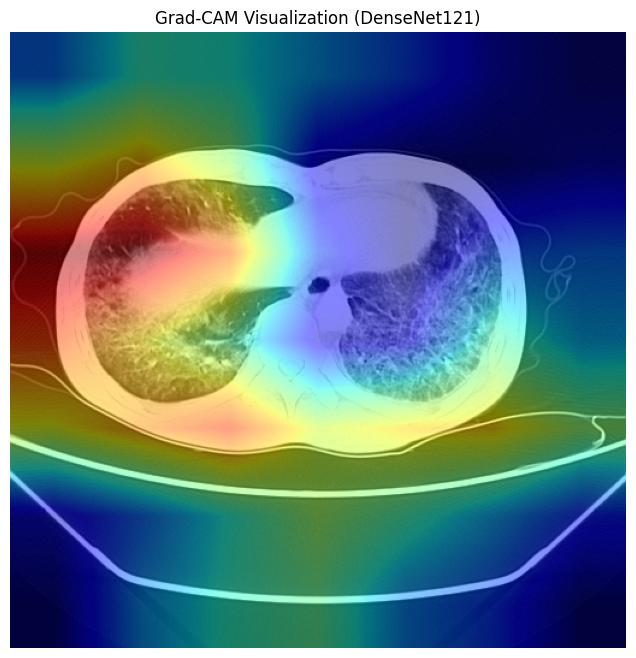

Saved Grad-CAM visualization at: gradcam_output_custom_densenet121.jpg


In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
import os

model = DenseNet121(weights='imagenet')

# Image preprocessing function (for your CT images)
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

# Grad-CAM generation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block16_concat", pred_index=None):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

# Overlay heatmap on original image
def overlay_heatmap(heatmap, img_path, alpha=0.4, cmap='jet'):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap_resized = np.uint8(255 * heatmap_resized[:, :, 0])

    jet = plt.cm.get_cmap(cmap)
    colored_heatmap = jet(heatmap_resized / 255.0)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    superimposed_img = img * (1 - alpha) + colored_heatmap * alpha
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Run visualization
def run_gradcam(img_path, save_path=None):
    img_array = preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model)
    superimposed_img = overlay_heatmap(heatmap, img_path)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title("Grad-CAM Visualization (DenseNet121)")
    plt.show()

    # Save the image if a path is given
    if save_path:
        superimposed_img.save(save_path)
        print(f"Saved Grad-CAM visualization at: {save_path}")

# Example image path (replace with your test image)
img_path = "/content/test/pneumonia_CT/200 (63).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_densenet121.jpg")


<ipython-input-7-55978902e453>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


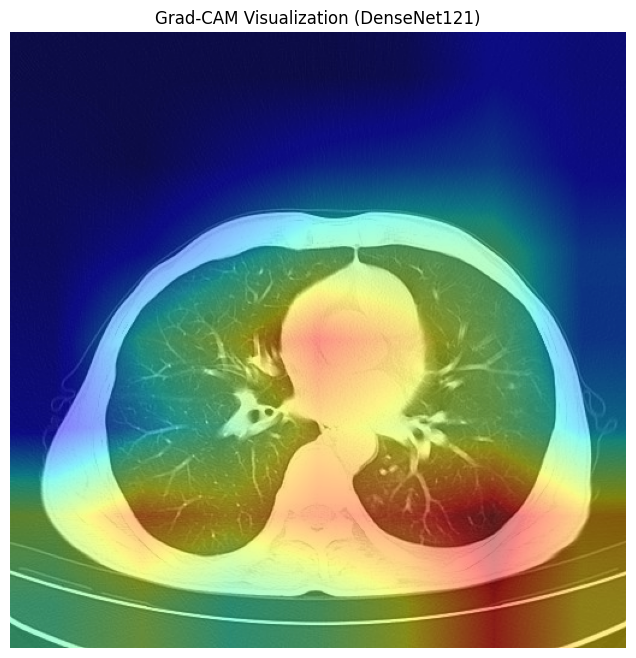

Saved Grad-CAM visualization at: gradcam_output_custom_densenet121_2.jpg


In [8]:
img_path = "/content/test/pneumonia_CT/2584 (25).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_densenet121_2.jpg")

<ipython-input-7-55978902e453>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


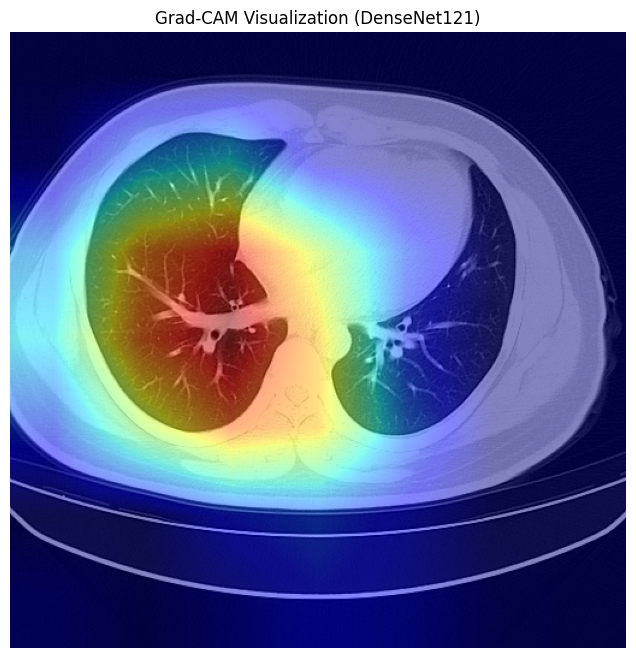

Saved Grad-CAM visualization at: gradcam_output_custom_densenet121_3.jpg


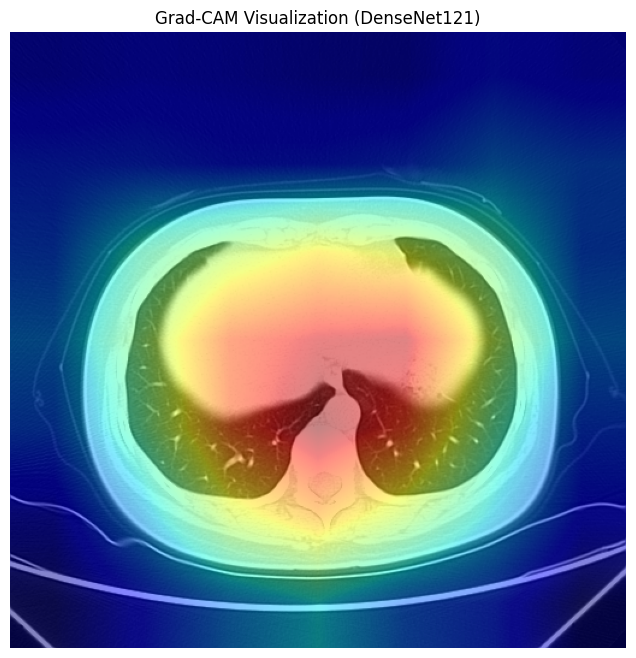

Saved Grad-CAM visualization at: gradcam_output_custom_densenet121_4.jpg


In [9]:
img_path = "/content/test/Normal_CT/23985k (6).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_densenet121_3.jpg")

img_path2 = "/content/test/Normal_CT/dsvcsdlk (11).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path2, save_path="gradcam_output_custom_densenet121_4.jpg")

<ipython-input-10-250fb3e6e790>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


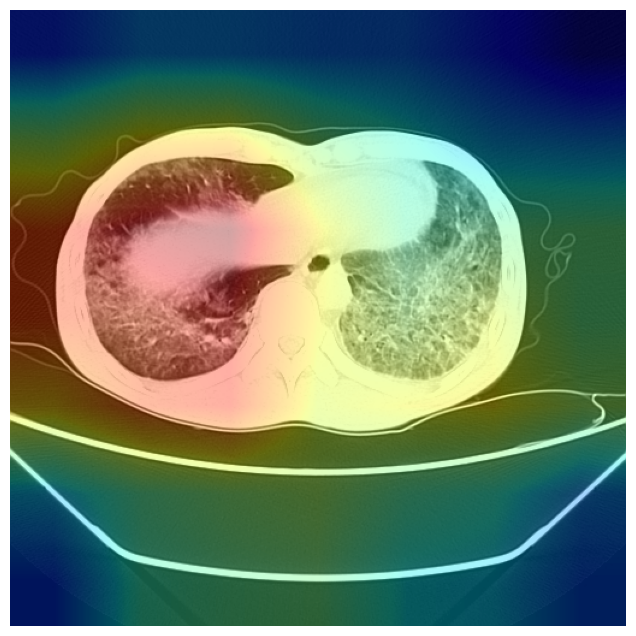

In [10]:
#Implementation of CAM on CT Scan images
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


model = DenseNet121(weights="imagenet")

# Function to preprocess input image
def preprocess_image(img_path, target_size=(224,224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

# Function to compute Class Activation Mapping (CAM)
def compute_cam(img_array, model, last_conv_layer_name, class_idx=None):
    # Create a model that maps input image to the activations of the last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.models.Model(model.input, last_conv_layer.output)

    # Get the classification layer weights
    classifier_weights = model.layers[-1].get_weights()[0]  # Final dense layer weights

    # Compute the feature maps and predictions
    feature_maps = last_conv_model(img_array)
    predictions = model(img_array)

    if class_idx is None:
        class_idx = np.argmax(predictions[0])

    # Get the weights for the specific class
    class_weights = classifier_weights[:, class_idx]

    # Compute the weighted sum of feature maps
    cam = tf.reduce_sum(feature_maps[0] * class_weights, axis=-1)

    # Normalize CAM
    cam = tf.maximum(cam, 0)  # ReLU operation
    cam = cam / tf.reduce_max(cam)
    return cam.numpy()

# Function to overlay CAM on original image
def overlay_cam(cam, img_path, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    # Resize CAM to the size of the original image
    cam = np.uint8(255 * cam)
    cam = tf.image.resize(np.expand_dims(cam, axis=-1), (img.shape[0], img.shape[1])).numpy()
    cam = np.uint8(cam[:, :, 0])

    # Create a colored heatmap
    jet = plt.cm.get_cmap("jet")
    jet_heatmap = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_heatmap * 255)
    colored_heatmap = jet_heatmap[cam]

    # Overlay the heatmap on the image
    superimposed_img = colored_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

# Test with an example image
img_path = "/content/test/pneumonia_CT/200 (63).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block16_concat")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

<ipython-input-10-250fb3e6e790>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


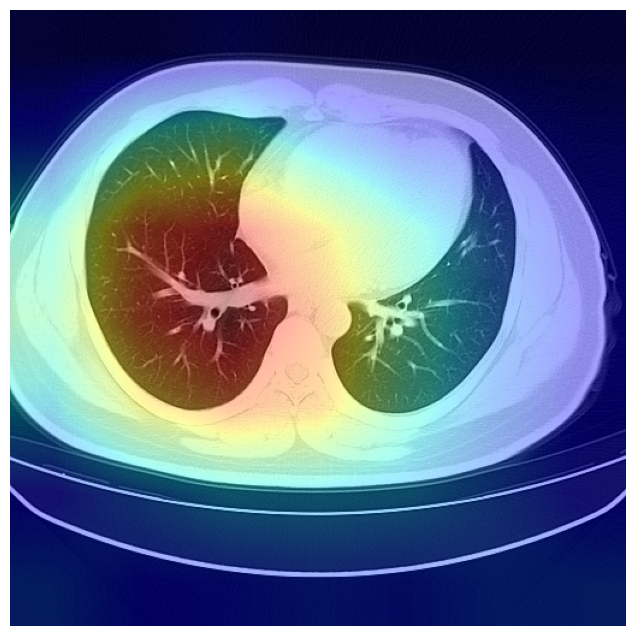

In [11]:
# Test with an example image
img_path = "/content/test/Normal_CT/23985k (6).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block16_concat")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

<ipython-input-10-250fb3e6e790>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


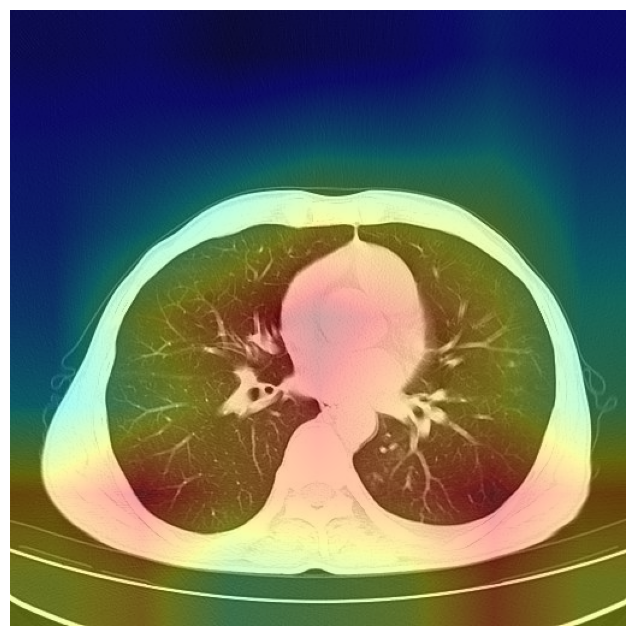

In [12]:
# Test with an example image
img_path = "/content/test/pneumonia_CT/2584 (25).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block16_concat")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

<ipython-input-10-250fb3e6e790>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


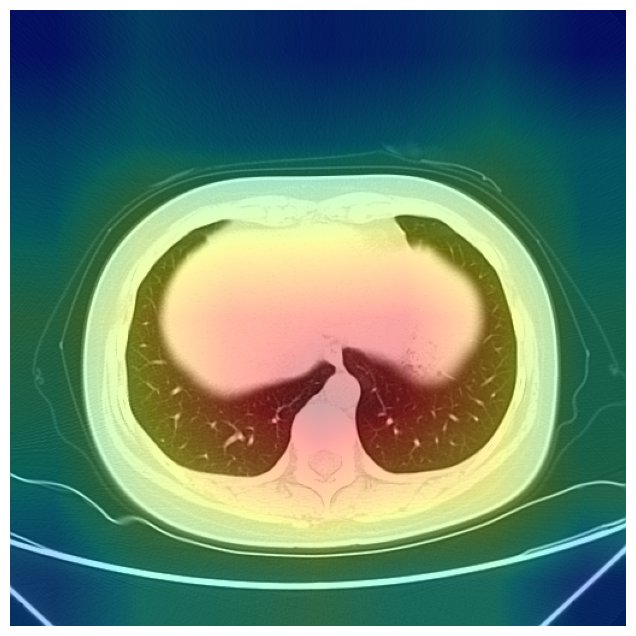

In [13]:
# Test with an example image
img_path = "/content/test/Normal_CT/dsvcsdlk (11).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block16_concat")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

In [14]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c5593e9d377072d763783c0cae3e1f96c49fff287d38f1eaa5e7210b1a0f178c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n02910353', 'buckle', np.float32(0.25285655)), ('n04019541', 'puck', np.float32(0.059021346)), ('n03929660', 'pick', np.float32(0.050431833))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

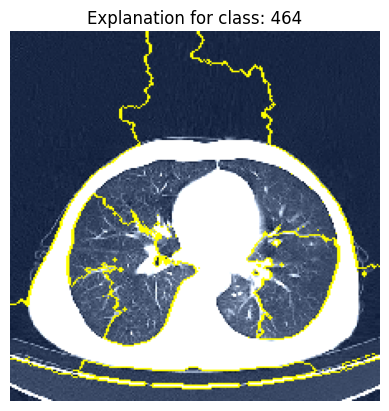

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
Predicted: [('n03633091', 'ladle', np.float32(0.15021634)), ('n03920288', 'Petri_dish', np.float32(0.11231934)), ('n04033901', 'quill', np.float32(0.065591656))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

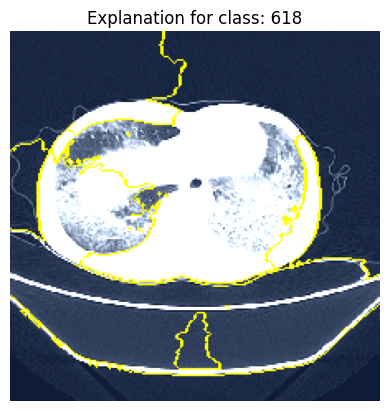

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Predicted: [('n04548280', 'wall_clock', np.float32(0.36364287)), ('n02708093', 'analog_clock', np.float32(0.20932)), ('n07930864', 'cup', np.float32(0.053642903))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

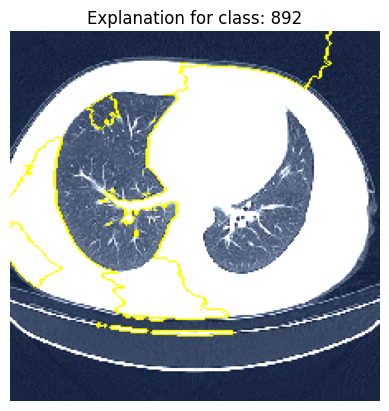

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Predicted: [('n02910353', 'buckle', np.float32(0.5035951)), ('n01930112', 'nematode', np.float32(0.12569556)), ('n07930864', 'cup', np.float32(0.030551316))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

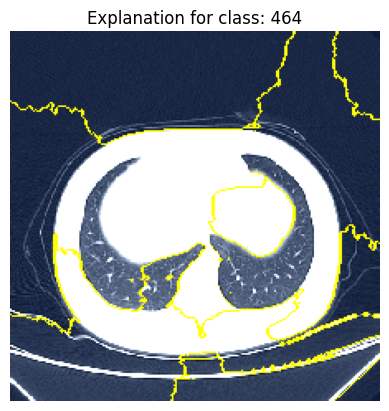

In [15]:
#Applying LIME XAI technique

import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_image_with_lime(model, img_path):
    """
    Explains the prediction of a model on a given image using LIME.

    Parameters:
    - model: A pre-trained model that will be used to make predictions.
    - img_path: The path to the image to be explained.

    Returns:
    - None: The function displays the image with LIME explanations.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224,224))  # Adjust the target size according to your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = model.preprocess_input(img_array)  # Replace with your model's preprocess function if needed

    # Get the model's prediction
    preds = model.predict(img_array)
    print('Predicted:', model.decode_predictions(preds, top=3)[0])  # Adjust this according to your model

    # Initialize LIME image explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        img_array[0].astype('double'),
        model.predict,
        top_labels=5,
        hide_color=0,
        num_samples=1000
    )

    # Get the explanation for the top predicted label
    top_label = np.argmax(preds)
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # Display the image with boundaries
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f"Explanation for class: {top_label}")
    plt.axis('off')
    plt.show()

# Example usage:
if __name__ == "__main__":
    from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input, decode_predictions
    model = DenseNet121(weights='imagenet')
    model.preprocess_input = preprocess_input  # Add preprocess and decode functions to the model object
    model.decode_predictions = decode_predictions

    img_path = '/content/test/pneumonia_CT/2584 (25).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path)

    img_path2='/content/test/pneumonia_CT/200 (63).jpg'

    explain_image_with_lime(model, img_path2)

    img_path3 = '/content/test/Normal_CT/23985k (6).jpg'


    explain_image_with_lime(model, img_path3)

    img_path4 = '/content/test/Normal_CT/dsvcsdlk (11).jpg'

    explain_image_with_lime(model, img_path4)